<a href="https://colab.research.google.com/github/suna-slgl/Decision-Oriented-Vehicle-Segmentation-Engine/blob/main/Decision_Oriented_Vehicle_Segmentation_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



> ***Decision Oriented Vehicle Segmentation Engine***
>
> *This study proposes a hybrid and explainable vehicle segmentation architecture that integrates ElasticNet-based supervised feature selection with PCA-driven unsupervised clustering and probabilistic segmentation using Gaussian Mixture Models. The proposed framework segments vehicles into economic, performance, and premium categories while modeling uncertainty at segment boundaries, thereby enabling interpretable and data-driven analysis.*





> ***Karar Odaklı Araç Segmentasyon Motoru***
>
> *Bu çalışmada, ElasticNet’e dayalı denetimli özellik seçimi ile PCA destekli denetimsiz kümeleme ve Gaussian Mixture Model kullanılarak gerçekleştirilen olasılıksal segmentasyonu bir araya getiren hibrit ve açıklanabilir bir araç segmentasyon mimarisi önerilmektedir. Geliştirilen yapı, araçları ekonomik, performans ve premium segmentlere ayırırken segment sınırlarındaki belirsizliği modelleyerek yorumlanabilir ve veri temelli analiz imkânı sunmaktadır.*

> [Dataset Kaggle Link](www.kaggle.com/datasets/urvishahir/electric-vehicle-specifications-dataset-2025)



In [6]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/urvishahir/electric-vehicle-specifications-dataset-2025")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sunaslgl
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/urvishahir/electric-vehicle-specifications-dataset-2025


100%|██████████| 16.2k/16.2k [00:00<00:00, 45.5MB/s]

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import ElasticNet
from sklearn.feature_selection import SelectFromModel
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.mixture import GaussianMixture

In [8]:
# veriset ve feature tanımı

dataset = pd.read_csv("/content/electric-vehicle-specifications-dataset-2025/electric_vehicles_spec_2025.csv.csv")

numeric_features = [
    "top_speed_kmh",
    "battery_capacity_kWh",
    "number_of_cells",
    "torque_nm",
    "efficiency_wh_per_km",
    "acceleration_0_100_s",
    "fast_charging_power_kw_dc",
    "towing_capacity_kg",
    "cargo_volume_l",
    "seats",
    "length_mm",
    "width_mm",
    "height_mm"
]

categorical_features = [
    "battery_type",
    "fast_charge_port",
    "drivetrain"
]

# brand, model, segment, car_body_type, source_url feature'ları modele dahil edilemez.


for col in numeric_features:
    if col in dataset.columns:
        dataset[col] = pd.to_numeric(dataset[col], errors="coerce")

X = dataset[numeric_features + categorical_features]
y = dataset["range_km"]


In [9]:
# PREPROCESSING PIPELINES

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [10]:
# ELASTICNET + FEATURE SELECTION

elastic_net = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    random_state=42
)

feature_selector = SelectFromModel(
    estimator=elastic_net,
    threshold="median"
)


In [11]:
# PCA + KMEANS

pca = PCA(
    n_components=0.80,
    random_state=42
)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)


In [12]:
# Final Pipeline
segmentation_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("feature_selection", feature_selector),
    ("pca", pca),
    ("kmeans", kmeans)
])



In [13]:
# FIT & PREDICT

segmentation_pipeline.fit(X, y)

dataset["ev_segments"] = segmentation_pipeline.predict(X)

In [14]:
dataset["ev_segments"].value_counts()

,count
ev_segments,
1,176
0,166
3,87
2,49


In [19]:
# kmeans ile oluşturulan 4 adet segmentin özelliklerine göre etiketlendirilmesi

profile_cols = [
    "range_km",             # kullanım kapasitesi
    "battery_capacity_kWh", # enerji büyüklüğü
    "top_speed_kmh",        # performans
    "torque_nm",            # performans
    "efficiency_wh_per_km", # ekonomik/şehir içi uygunluk
    "acceleration_0_100_s", # sportiflik (küçük = hızlı)
    "length_mm"             # araç sınıfı (küçük ↔ büyük)
]

dataset.groupby("ev_segments")[profile_cols].mean().round(2)

,range_km,battery_capacity_kWh,top_speed_kmh,torque_nm,efficiency_wh_per_km,acceleration_0_100_s,length_mm
ev_segments,,,,,,,
0,481.66,93.96,220.36,739.64,178.31,4.63,4947.79
1,402.53,71.90,179.23,442.77,148.73,6.74,4614.49
2,250.92,61.59,140.88,331.71,213.33,11.56,4971.92
3,285.57,47.41,156.75,256.27,133.78,8.84,4128.95


**0. Segment Sonucu:** Büyük, güçlü, uzun menzilli, pahalı olması çok muhtemel. (Premium / Luxury EV)

**1. Segment Sonucu:** Dengeli, ana akım, aile kullanımı. (Mainstream / Mid-range EV)

**2. Segment Sonucu:** Performansı düşük, verimlilik odaklı değil, muhtemelen eski veya ağır platform. (Low-performance / Utility EV)

**3. Segment Sonucu:** Küçük, verimli, şehir içi odaklı. (City / Economic EV)



In [20]:
segment_names = {
    0: "Premium / Yüksek Performanslı Elektrikli Araçlar",     # Premium / Performance EV
    1: "Ana Akım / Dengeli Elektrikli Araçlar",                # Mainstream / Balanced EV
    2: "Fayda Odaklı / Düşük Performanslı Elektrikli Araçlar", # Utility / Low-Performance EV
    3: "Şehir İçi / Ekonomik Elektrikli Araçlar"               # City / Economic EV
}

# GÖRSELLEŞTİRME

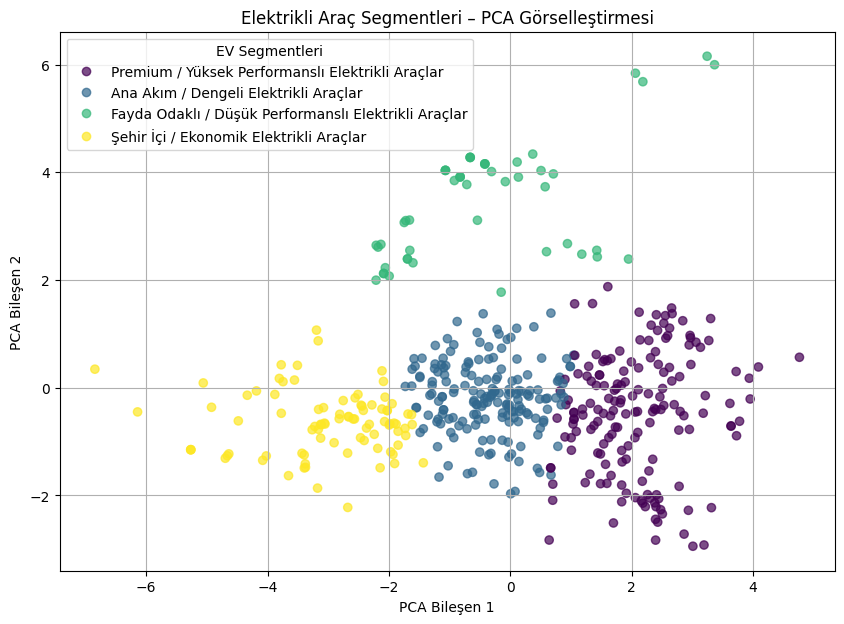

In [22]:
# PCA / TEMEL BİLEŞEN ANALİZİ

# Pipeline'dan dönüşümler
X_transformed = segmentation_pipeline.named_steps["preprocessing"].transform(X)
X_selected = segmentation_pipeline.named_steps["feature_selection"].transform(X_transformed)

# PCA (2 bileşen)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_selected)

labels = dataset["ev_segments"]

# Plot
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=labels,
    alpha=0.7
)

handles, _ = scatter.legend_elements()
legend_labels = [segment_names[i] for i in sorted(labels.unique())]

plt.legend(handles, legend_labels, title="EV Segmentleri")
plt.xlabel("PCA Bileşen 1")
plt.ylabel("PCA Bileşen 2")
plt.title("Elektrikli Araç Segmentleri – PCA Görselleştirmesi")
plt.grid(True)
plt.show()

**PCA GRAFİK YORUMU**

X ve Y ekseni verideki en büyük varyansı taşıyan iki yöndür.

X ekseni **→** en büyük varyans yönünü ifade eder.

Y ekseni **→** ikinci büyük varyans yönünü ifade eder.

---

🟣 Segment 0 (Premium / Performans EV)
*   Yüksek hız
*   Yüksek tork
*   Büyük batarya
*   Uzun gövde

🔵 Segment 1 (Mainstream / Orta Segment EV)
*   Dengeli menzil
*   Ortalama batarya
*   Ortalama performans


🟢 Segment 2 (Efficiency-Oriented / Uzun Menzil EV)
*   Verimlilik
*   Menzil / batarya oranı
*   Muhtemelen aerodinamik veya özel kullanım


🟡 Segment 3 (Şehir içi / Ekonomik EV)
*   Küçük batarya
*   Düşük menzil
*   Kısa gövde
*   Daha yavaş













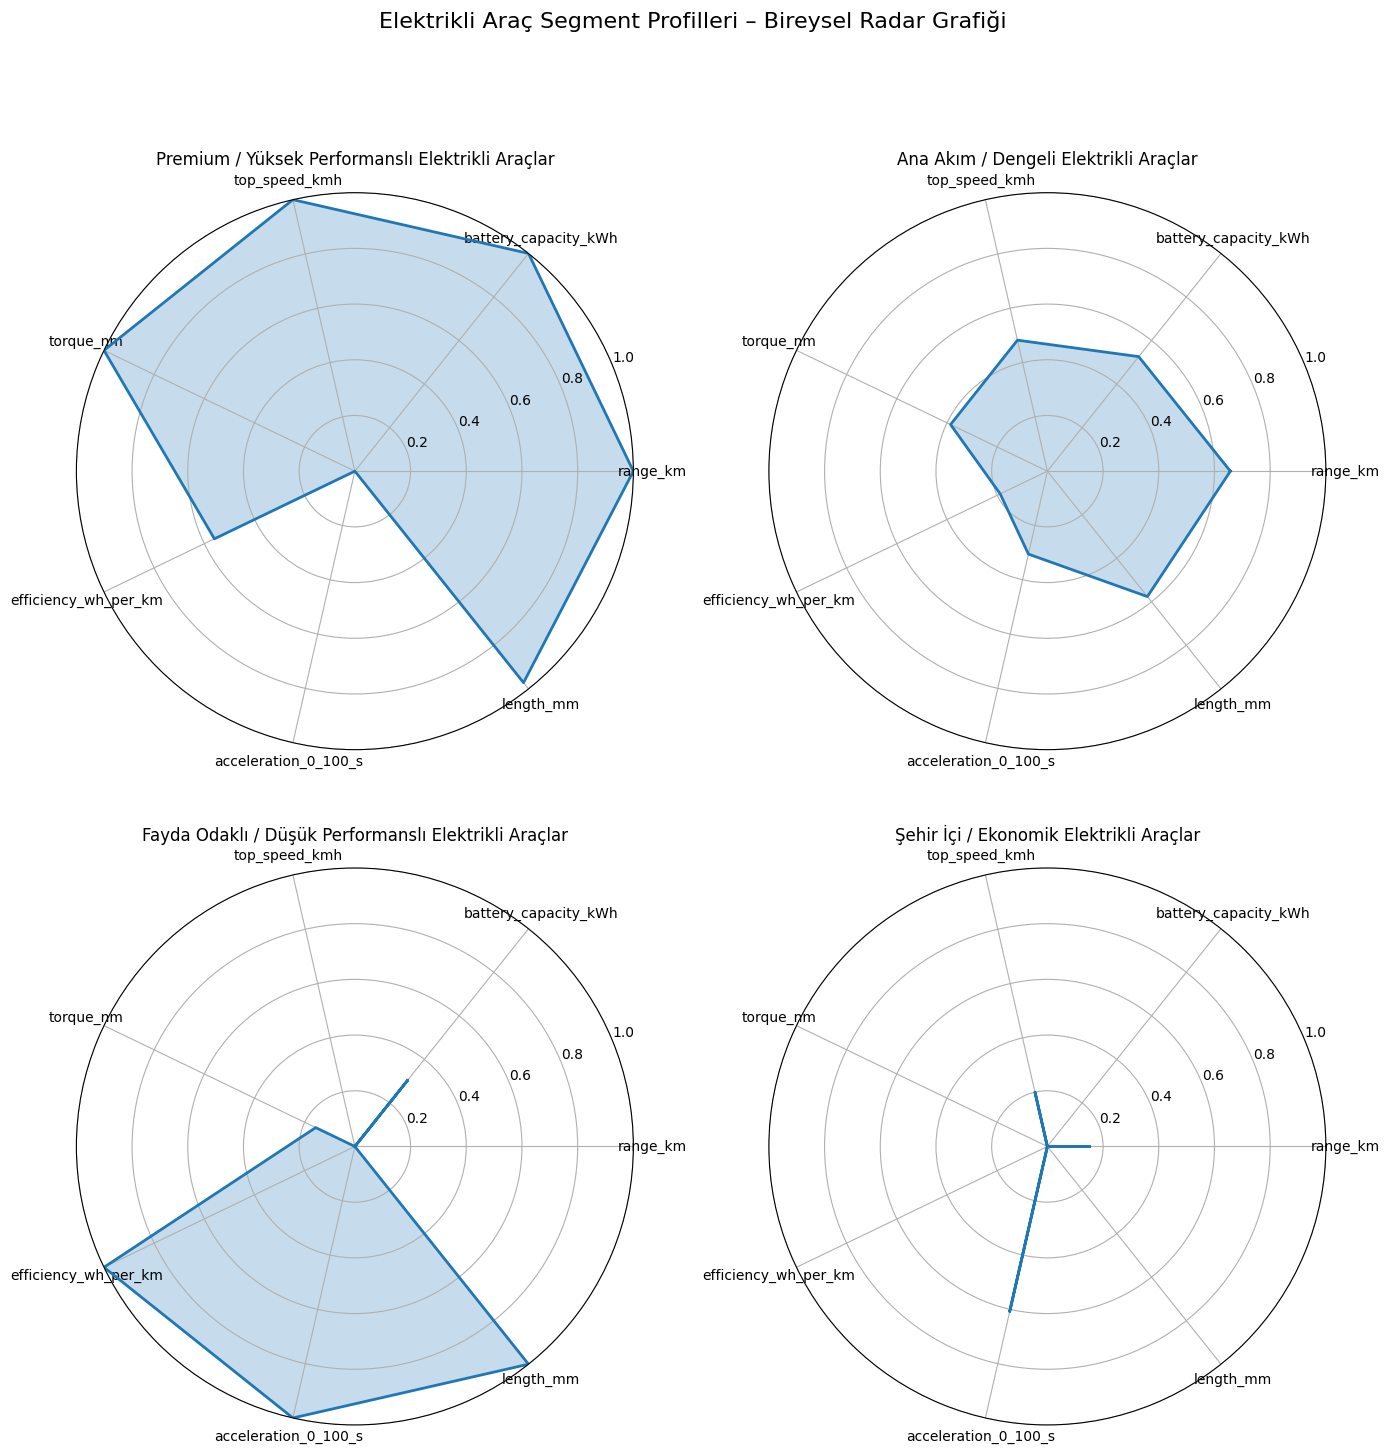

In [24]:
# INDIVIDUAL RADAR CHART / BİREYSEL RADAR GRAFİĞİ

profile_cols = [
    "range_km",
    "battery_capacity_kWh",
    "top_speed_kmh",
    "torque_nm",
    "efficiency_wh_per_km",
    "acceleration_0_100_s",
    "length_mm"
]

# Segment ortalamaları
segment_profiles = dataset.groupby("ev_segments")[profile_cols].mean()

# Normalizasyon (radar için şart)
profiles_norm = (segment_profiles - segment_profiles.min()) / (
    segment_profiles.max() - segment_profiles.min()
)

labels = profile_cols
num_vars = len(labels)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# 2x2 radar layout
fig, axes = plt.subplots(2, 2, figsize=(14, 14), subplot_kw=dict(polar=True))
axes = axes.flatten()

for ax, seg in zip(axes, profiles_norm.index):
    values = profiles_norm.loc[seg].tolist()
    values += values[:1]

    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_ylim(0, 1)
    ax.set_title(segment_names[seg], pad=20)

plt.suptitle("Elektrikli Araç Segment Profilleri – Bireysel Radar Grafiği", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# Yeni Bölüm

In [36]:
# Segment profili oluşturma

gmm_features = [
    "range_km",
    "battery_capacity_kWh",
    "top_speed_kmh",
    "torque_nm",
    "acceleration_0_100_s",
    "length_mm"
]

segment_profiles = (
    dataset.groupby("ev_segments")[gmm_features]
      .mean()
)


In [38]:
# GMM için Scale

scaler = StandardScaler()
segment_profiles_scaled = scaler.fit_transform(segment_profiles)

In [40]:
# GMM

gmm = GaussianMixture(
    n_components=3,
    random_state=42,
    covariance_type="full"
)

gmm_labels = gmm.fit_predict(segment_profiles_scaled)
gmm_probs = gmm.predict_proba(segment_profiles_scaled)

In [42]:
# GMM cluster'larını anlamlandırma ve eşleme

gmm_centers = pd.DataFrame(
    scaler.inverse_transform(gmm.means_),
    columns=gmm_features
)

gmm_centers

gmm_market_map = {
    0: "Ekonomik",
    1: "Orta",
    2: "Premium"
}

In [43]:
segment_market_df = segment_profiles.copy()

segment_market_df["Market_Segment"] = [
    gmm_market_map[label] for label in gmm_labels
]

segment_market_df["Premium_Prob"] = gmm_probs[:, list(gmm_market_map.values()).index("Premium")]

segment_market_df


,range_km,battery_capacity_kWh,top_speed_kmh,torque_nm,acceleration_0_100_s,length_mm,Market_Segment,Premium_Prob
ev_segments,,,,,,,,
0,481.656627,93.957831,220.355422,739.643750,4.627108,4947.789157,Premium,1.0
1,402.528409,71.895455,179.227273,442.772727,6.743182,4614.488636,Ekonomik,0.0
2,250.918367,61.585714,140.877551,331.714286,11.555102,4971.918367,Orta,0.0
3,285.574713,47.409195,156.747126,256.267442,8.836782,4128.954023,Ekonomik,0.0
